## **Telco Customer Churn:**

**Problem Statement:**

Predicting customer churn is a critical task for telecommunications companies. By accurately identifying customers at risk of leaving, businesses can implement targeted retention strategies to improve customer loyalty and reduce revenue loss.

**Dataset Overview:**

This dataset provides a comprehensive view of customer information, including demographic details, service usage, account information, and churn status. Each row represents a unique customer, and each column contains attributes relevant to customer churn analysis.

**Key Features:**

* **Churn:** Binary indicator of whether the customer churned in the last month.
* **Customer Information:** Includes tenure, contract type, payment method, and monthly charges.
* **Service Usage:** Details about services subscribed to, such as phone, internet, and streaming services.
* **Demographic Information:** Gender, age range, and information about partners and dependents.

**Goal:**

The primary goal of this analysis is to develop a predictive model that can accurately identify customers at risk of churning. By understanding the factors driving churn, we can implement targeted retention strategies to improve customer satisfaction and reduce churn rates.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#ignore warnings
import warnings
warnings.filterwarnings('ignore')
#display all data 
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
telco = pd.read_csv('Telco-Customer-Churn.csv')
telco.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
telco.isna().sum() #checking for missing values

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [4]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


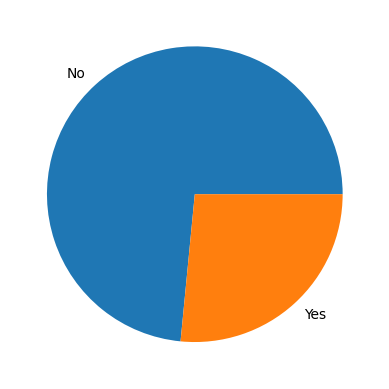

In [5]:
telco['Churn'].value_counts().plot(kind='pie')
plt.ylabel("")
plt.show()

## **Exploratory Data Analysis (EDA):**
- Analyze the data to identify key factors contributing to churn.
- Use visualization techniques (e.g., histograms, heatmaps, boxplots) to explore the relationship between different features and customer churn.
- Segment customers based on behavior, demographics, or engagement levels to better understand the drivers of churn.

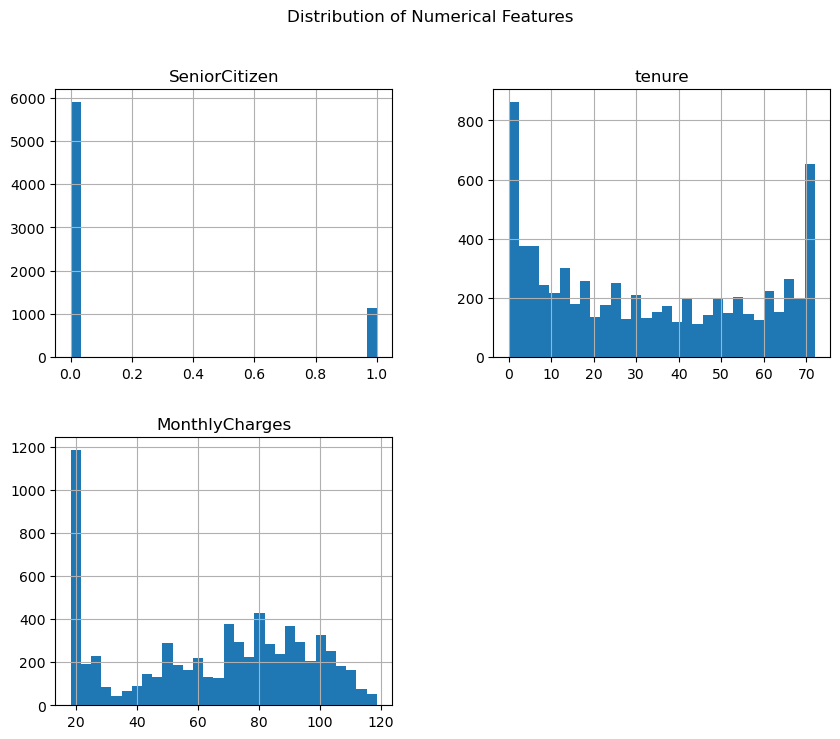

In [6]:
# Histogram of numerical features
numerical_columns = telco.select_dtypes(exclude='object').columns
telco[numerical_columns].hist(bins=30, figsize=(10, 8))
plt.suptitle('Distribution of Numerical Features')
plt.show()

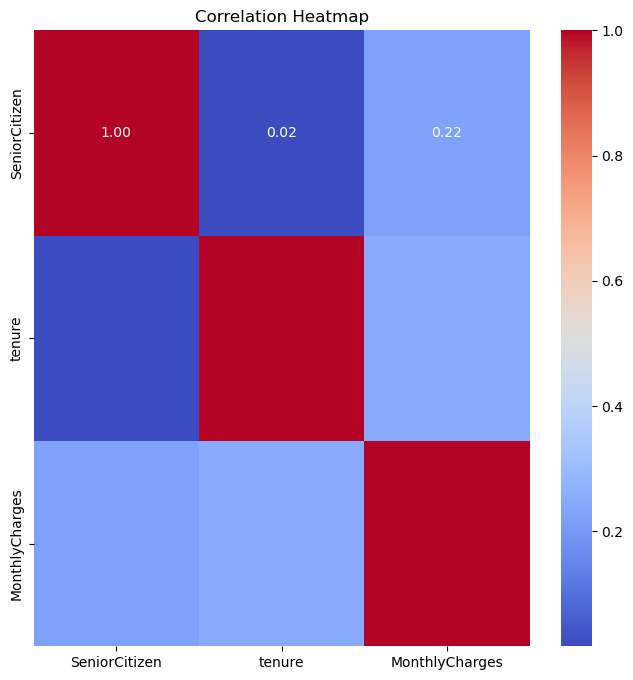

In [7]:
num_df = telco.select_dtypes(exclude='object')
# Heatmap to visualize correlations
plt.figure(figsize=(8, 8))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()



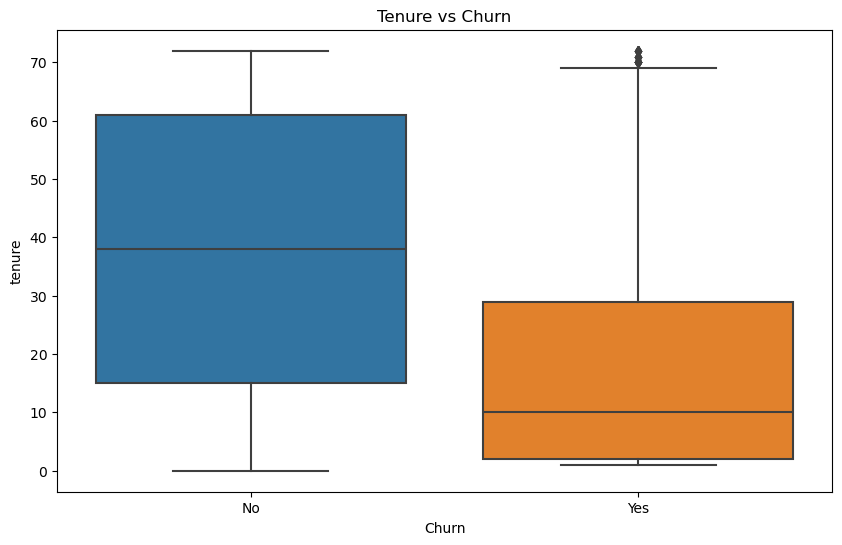

In [8]:
# Boxplot to see churn distribution across tenure
plt.figure(figsize=(10, 6))
sns.boxplot(x='Churn', y='tenure', data=telco)
plt.title('Tenure vs Churn')
plt.show()


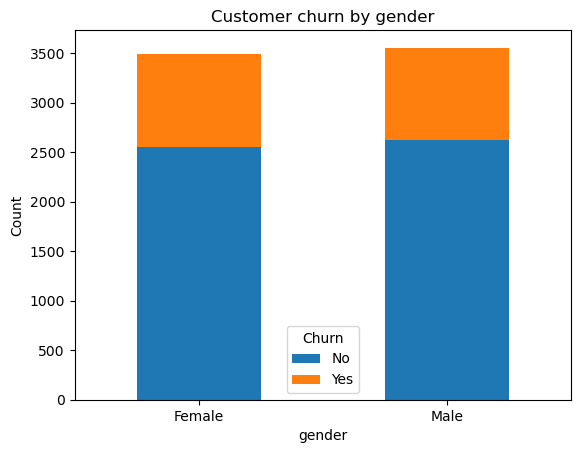

In [9]:
#customer churn by gender 
gender_churn = telco.groupby('gender')['Churn'].value_counts().unstack()
gender_churn.plot(kind="bar", stacked=True)
plt.title("Customer churn by gender")
plt.xlabel("gender")
plt.ylabel("Count")
plt.legend(title="Churn")
plt.xticks(rotation=0)
plt.show();

## **Data preprocessing** 

In [10]:
#dropping the unnecessary columns
telco.drop(columns='customerID',axis=1, inplace=True)

In [11]:
telco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


**The TotalCharges column is represented as having object type when in real sense it has float data type and we have to change that before proceeding to encoding and scaling**

In [12]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

def preprocess_data(df):
    # Identify categorical and numerical columns
    categorical_columns = df.select_dtypes(include=['object', 'category']).columns
    numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']
    
    # Convert 'TotalCharges' to numeric, coercing errors to NaN
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    
    # Encode categorical columns using LabelEncoder
    for col in categorical_columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
    
    # Scale numerical columns using MinMaxScaler
    scaler = MinMaxScaler()
    df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
    
    return df

# Applying the encoding and scaling function to the data
telco_df = preprocess_data(telco)



In [13]:
telco_df.head(4)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,0.013889,0,1,0,0,2,0,0,0,0,0,1,2,0.115423,0.011332,0
1,1,0,0,0,0.472222,1,0,0,2,0,2,0,0,0,1,0,3,0.385075,0.554977,0
2,1,0,0,0,0.027778,1,0,0,2,2,0,0,0,0,0,1,3,0.354229,0.082083,1
3,1,0,0,0,0.625000,0,1,0,2,0,2,2,0,0,1,0,0,0.239303,0.546708,0




## **Model Development:**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE # address the imbalance in the target feature 


In [15]:
# Separate features and target
X = telco.drop(['Churn'], axis=1)
y = telco['Churn']

# Select the top features
selected_features = ['TotalCharges', 'MonthlyCharges', 'Contract', 'tenure', 
                     'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 
                     'InternetService', 'MultipleLines', 'OnlineBackup']

# Filter the dataset to include only the selected features
X = X[selected_features]

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
# Apply SMOTE to the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [17]:
# Function to train models and visualize evaluation metrics
def train_and_evaluate_models(X_train_resampled, X_test, y_train_resampled, y_test):
    # Defining and initializing the models
    models = {
        'Logistic Regression': LogisticRegression(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'Gradient Boosting': GradientBoostingClassifier(random_state=42),
        'Neural Network': MLPClassifier(random_state=42, max_iter=1000),
        'Random Forest': RandomForestClassifier(),
        'Gradient Boost':GradientBoostingClassifier() 
    }
    
    # Lists to store results
    names = []
    accuracy_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []
    roc_auc_scores = []
    
    # Train and evaluate each model
    for name, model in models.items():
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probability scores for ROC AUC

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        names.append(name)
        accuracy_scores.append(accuracy)
        precision_scores.append(precision)
        recall_scores.append(recall)
        f1_scores.append(f1)
        roc_auc_scores.append(roc_auc)

        print(f"{name} - Accuracy: {accuracy:.3f}, Precision: {precision:.3f}, Recall: {recall:.3f}, F1: {f1:.3f}, ROC AUC: {roc_auc:.3f}")
        
    # Visualize evaluation metrics in bar charts
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']
    scores = [accuracy_scores, precision_scores, recall_scores, f1_scores, roc_auc_scores]
    colors = ['blue', 'green', 'red', 'purple', 'orange']

    plt.figure(figsize=(12, 8))
    for i, metric in enumerate(metrics):
        plt.bar(names, scores[i], color=colors[i], alpha=0.6, label=metric)

    plt.xlabel('Model')
    plt.ylabel('Scores')
    plt.title('Evaluation Metrics of Different Classification Models')
    plt.legend()
    plt.show()


Logistic Regression - Accuracy: 0.752, Precision: 0.520, Recall: 0.818, F1: 0.635, ROC AUC: 0.859
Random Forest - Accuracy: 0.756, Precision: 0.533, Recall: 0.625, F1: 0.575, ROC AUC: 0.818
Gradient Boosting - Accuracy: 0.750, Precision: 0.518, Recall: 0.818, F1: 0.634, ROC AUC: 0.853
Neural Network - Accuracy: 0.737, Precision: 0.503, Recall: 0.802, F1: 0.618, ROC AUC: 0.850
Gradient Boost - Accuracy: 0.750, Precision: 0.518, Recall: 0.818, F1: 0.634, ROC AUC: 0.853


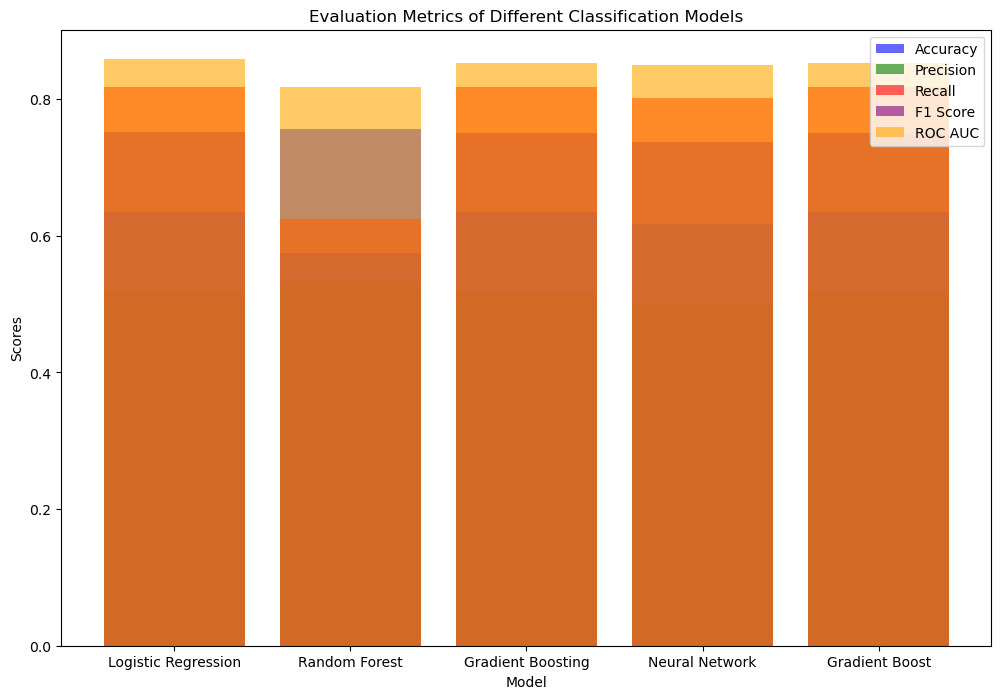

In [18]:
train_and_evaluate_models(X_train_resampled, X_test, y_train_resampled, y_test)

From the model performances above, we can see that Logistic Regression is the best model for this problem as it has the highest performance in almost all the metrics. 

In [19]:
# Step 1: Hyperparameter Tuning with Grid Search and Cross-Validation

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the hyperparameter grid for Logistic Regression
param_grid = {
    'C': [0.1, 2, 4, 5],  # Regularization parameter
    'solver': ['liblinear', 'saga']  # Solvers to handle different types of datasets
}

# Initialize the Grid Search with Cross-Validation
grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='accuracy')

# Fit the model with training data
grid_search.fit(X_train_resampled, y_train_resampled)

# Get the best parameters and the best score from the Grid Search
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)


Best Parameters: {'C': 4, 'solver': 'saga'}
Best Cross-Validation Score: 0.752175007662332


In [20]:
#evaluating the tuned model
best_model = grid_search.best_estimator_

# Predicting on the test set
y_pred = best_model.predict(X_test)

# Evaluating the model performance
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])

print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"ROC AUC: {roc_auc:.3f}")


Accuracy: 0.749
Precision: 0.517
Recall: 0.807
F1 Score: 0.630
ROC AUC: 0.858


## **Interpretability and Feature Importance:**


**Using SHAP for feature importance**

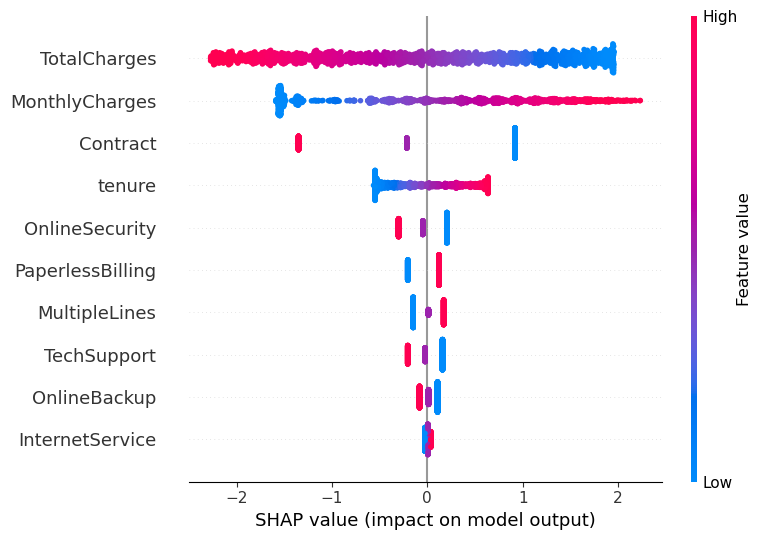

In [21]:
import shap

# Initialize the SHAP explainer using the model and training data
explainer = shap.Explainer(best_model, X_train)

# Calculate SHAP values for the test data
shap_values = explainer(X_test)

# Visualize the SHAP summary plot
shap.summary_plot(shap_values, X_test)


In [22]:
shap.initjs()  # Initialize JavaScript for interactive plots

# Interactive force plot for the first prediction
shap.force_plot(explainer.expected_value, shap_values.values[0], X_test.iloc[0, :], matplotlib=False)


**Factors Driving Customer Churn**

From the SHAP summary and force plots, we can make the following conclusions about the factors influencing churn as predicted by the model. 

1. **Monthly Charges:** This factor is the most significant factor driving churn. Customers with higher monthly charges are more likely to churn unlike those with fewer monthly charges. 
2. **Tenure:** While less impactful than MonthlyCharges, tenure still plays a role. Longer-tenured customers might be less likely to churn, but this effect is not as strong as the impact of higher monthly charges.
3. **Service Bundles:** The absence of services like OnlineBackup, TechSupport, OnlineSecurity, and PhoneService can contribute to churn. Customers who rely on these services might be less likely to churn.
4. **Contract Type:** The contract type is also another key factor affecting churn. Customers with shorter-term or month-to-month contracts might be more likely to churn compared to those with longer-term contracts.

**Potential Actions to Reduce Customer Churn:**

1. **Re-evaluate Pricing:** Consider adjusting pricing plans or offering discounts to customers with high monthly charges.
2. **Promote Value-Added Services:** Encourage customers to add services like OnlineBackup, TechSupport, and OnlineSecurity to increase customer stickiness.
3. **Offer Incentives for Longer-Term Contracts:** Provide incentives or discounts for customers who sign up for longer-term contracts.
4. **Improve Customer Satisfaction:** Focus on improving overall customer satisfaction, as it can help mitigate the impact of other factors.
5. **Implement a Churn Prediction System:** Use your model to proactively identify customers at risk of churning and take targeted actions to retain them.

## **Retention Strategy Development:**

### Actionable strategies from the churn model

1. **Engage in targetd marketing campaigns:**
   * **Offer Discounts:** From the SHAP plot, we saw that customers who pay more have higher chances of churning. Giving these customers discounts can help reduce the chances of churning. 
   * **Offer personalized recommendations:** Use the customer data to recommend additional services that align with their needs and preferences.
   * **Introduce Loyalty Programs:** Implement a loyalty program that rewards long-term customers with exclusive benefits and discounts.

2. **Personalized Offers:**
   * **Customized Bundles:** Offer personalized service bundles tailored to individual customer needs and preferences.
   * **Upgrade Incentives:** Provide incentives for customers to upgrade their plans to higher-tier options.

3. **Improved Customer Service for High-Risk Customers:**
   * **Proactive Outreach:** Reach out to high-risk customers before they churn to address their concerns and offer solutions.
   * **Dedicated Support Channels:** Provide dedicated support channels for high-risk customers, ensuring they receive timely and personalized assistance.
   * **Customer Satisfaction Surveys:** Regularly conduct customer satisfaction surveys to identify areas for improvement and address issues promptly.

### Simulating the Potential Impact

To simulate the potential impact of these strategies, the following strategies can come in handy:

1. **A/B Testing:** Conduct controlled experiments to compare the effectiveness of different retention strategies on different customer segments.
2. **Customer Lifetime Value (CLV) Modeling:** Estimate the CLV of customers under different retention scenarios to assess the potential financial impact of each strategy.
3. **Scenario Analysis:** Create hypothetical scenarios to explore the potential outcomes of various retention strategies, such as reducing churn by 10% or increasing average revenue per user (ARPU) by 5%.

**By implemeting these strategies and simulating their potential impacts on customer churn, the company can develop targeted and effective customer retention plans that can greatly help improve customer loyalty and reduce churn.**



## **Saving the model**

In [24]:
import pickle

# saving the logistic regression model as a pickle file
model_pkl_file = "model.pkl"  

with open(model_pkl_file, 'wb') as file:  
    pickle.dump(best_model, file)

In [26]:
with open("model.pkl", "rb") as file:
    test_model = pickle.load(file)

In [29]:
test_model.predict([[0.455130,0.463682,1,0.291667,2,0,0,0,0,0]])

array([0])

In [30]:
test_model.predict([[0.006891,0.051741,0,0.013889,0,0,1,0,1,0]])

array([1])

In [32]:
X_train_resampled.columns

Index(['TotalCharges', 'MonthlyCharges', 'Contract', 'tenure',
       'OnlineSecurity', 'TechSupport', 'PaperlessBilling', 'InternetService',
       'MultipleLines', 'OnlineBackup'],
      dtype='object')